# TinyML — Generative Adversarial Networks (GAN)

**Author:** Thommas Kevin Sales Flores  
**Institution:** Federal University of Rio Grande do Norte  
**Email:** thommas.flores@ufrn.br

---

This notebook demonstrates how to build, train, and export **Generative Adversarial Networks** to embedded hardware (Arduino / ESP32) using the TinyML GAN framework.  
All examples use fully-connected architectures suitable for **tabular and low-dimensional data**.

### Supported GAN loss variants

| Key | Loss type | Best for |
|-----|-----------|----------|
| `vanilla` | Binary Cross-Entropy | Baselines, simple distributions |
| `lsgan` | Least-Squares | Smoother gradients, less mode collapse |
| `wgan` | Wasserstein + weight clipping | Improved stability |
| `wgan_gp` | Wasserstein + gradient penalty | Most stable, recommended |
| `hinge` | Hinge loss | Combined with spectral normalization |

### Architecture building blocks

| Component | Options |
|-----------|---------|
| **Activation** | `relu`, `leaky_relu`, `tanh`, `sigmoid`, `gelu`, `swish`, `linear` |
| **Generator norm** | `BatchNorm1d`, `ConditionalBatchNorm` (cGAN) |
| **Discriminator norm** | `LayerNorm` (WGAN-GP), spectral normalization (hinge) |


## Environment Setup


In [1]:
#!pip install torch numpy matplotlib scikit-learn

## 1. Setup and Imports


In [2]:
import sys, os
sys.path.append('37_GAN')   # adjust if running from a different directory

import torch
import torch.optim as optim
import numpy as np
from torch.utils.data import DataLoader, TensorDataset
from sklearn.datasets import make_moons, make_blobs
from sklearn.preprocessing import StandardScaler

from model  import Generator, Discriminator, ConditionalGAN
from layers import get_activation
from losses import compute_discriminator_loss, compute_generator_loss, LOSS_TYPES
from utils  import (
    export_to_json,
    GANTrainer,
    plot_training_history,
    plot_generated_samples,
    plot_latent_interpolation,
    plot_loss_landscape,
    evaluate_fid_proxy,
)
from cpp_generator import generate_ino, add_bn_stats_to_json

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', DEVICE)
print('Available loss types:', LOSS_TYPES)

os.makedirs('json_model',   exist_ok=True)
os.makedirs('arduino_code', exist_ok=True)

Device: cpu
Available loss types: ['vanilla', 'lsgan', 'wgan', 'wgan_gp', 'hinge']


---
## 2. Example 1 — Vanilla GAN on Two Moons

The classic `make_moons` dataset (2-D) demonstrates the basic GAN training loop.  
The Generator learns to produce samples that match the two-crescent distribution from 2-D Gaussian noise.

**Architecture:**
- Generator: `2 → 128 → 256 → 2` (BN + ReLU, tanh output)
- Discriminator: `2 → 256 → 128 → 1` (LeakyReLU + Dropout)
- Loss: Vanilla (non-saturating BCE)


=== Example 1 — Vanilla GAN: Two Moons ===
  Epoch    1/100  |  D loss = 1.38501  |  G loss = 0.69530
  Epoch   50/100  |  D loss = 0.96330  |  G loss = 1.42621
  Epoch  100/100  |  D loss = 0.95411  |  G loss = 1.44918


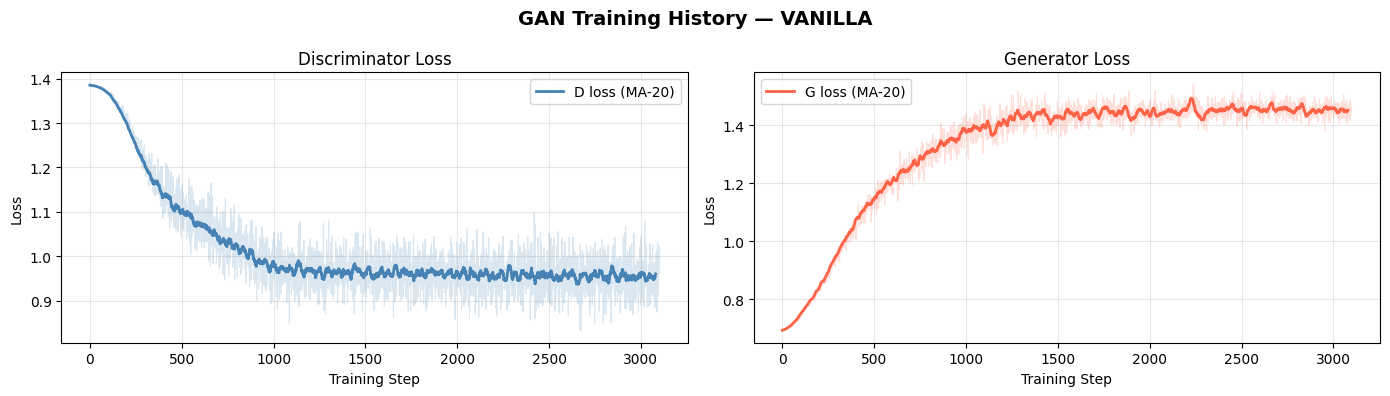

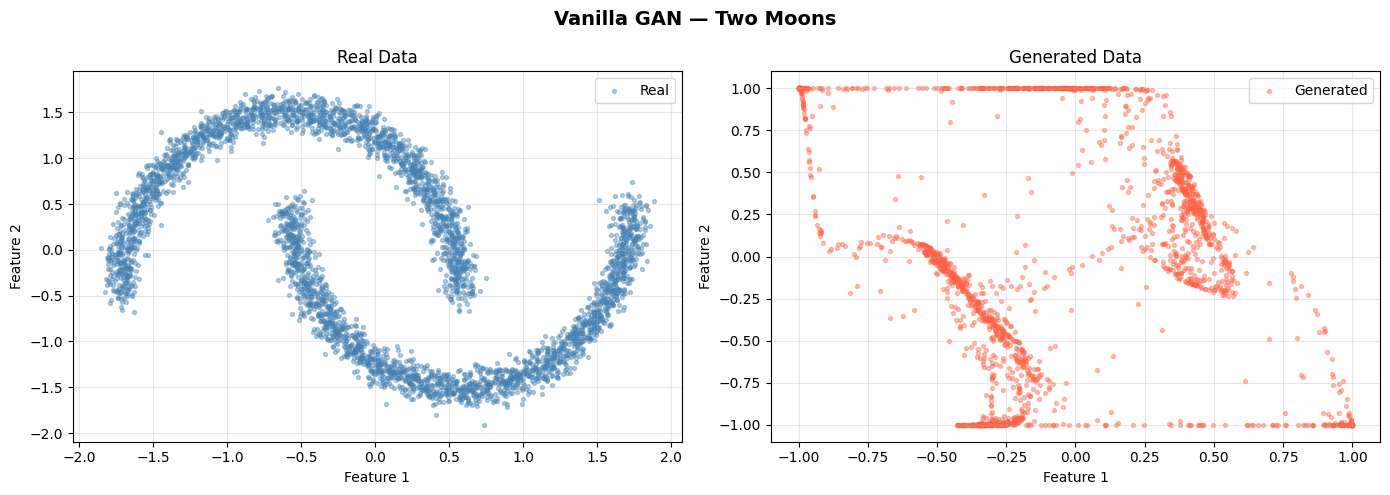

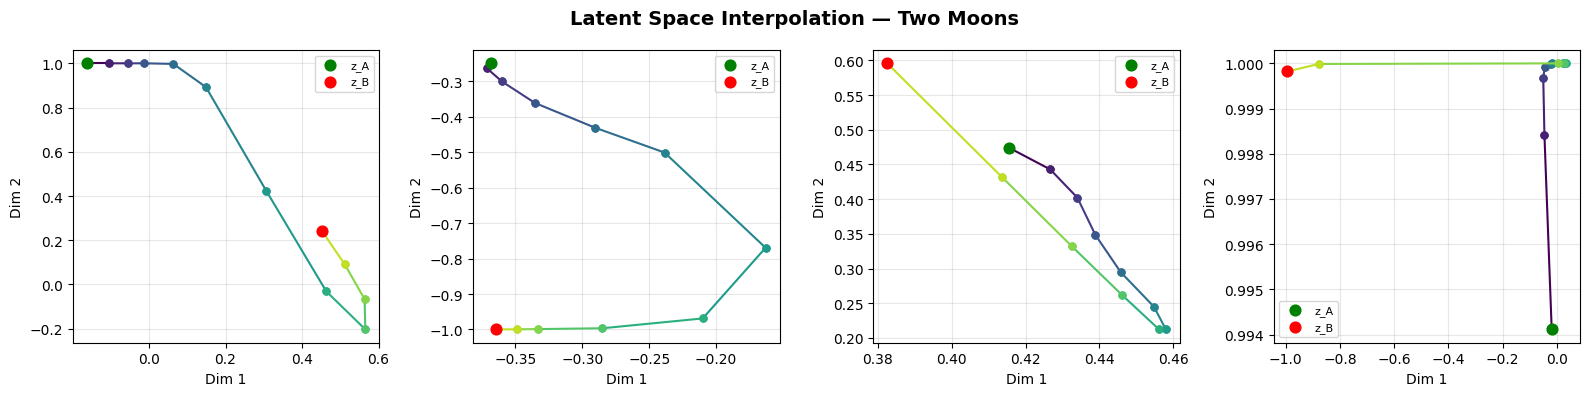

FID proxy: 0.3740
Generator exported → json_model/vanilla_moons_gen.json
BN running stats appended → json_model/vanilla_moons_gen.json
Generated in : arduino_code/vanilla_moons_ino  (board: esp32)
Latent dim   : 2  Output dim: 2
Conditional  : False  Classes: 0
Expected output (Python) : [-0.9977061152458191, 0.9999161958694458] ...


In [3]:
def train_vanilla_moons():
    print('=== Example 1 — Vanilla GAN: Two Moons ===')
    torch.manual_seed(42); np.random.seed(42)

    # ---- Data ----
    X, _ = make_moons(n_samples=4000, noise=0.05, random_state=42)
    scaler = StandardScaler()
    X = scaler.fit_transform(X).astype(np.float32)
    dataset = TensorDataset(torch.FloatTensor(X))
    loader  = DataLoader(dataset, batch_size=128, shuffle=True, drop_last=True)

    LATENT_DIM = 2

    # ---- Architecture ----
    G = Generator(
        latent_dim=LATENT_DIM,
        generator_layers=[
            {'out_features': 128, 'activation': 'relu',   'use_bn': True},
            {'out_features': 256, 'activation': 'relu',   'use_bn': True},
            {'out_features': 2,   'activation': 'tanh',   'use_bn': False},
        ],
    )
    D = Discriminator(
        input_dim=2,
        discriminator_layers=[
            {'out_features': 256, 'activation': 'leaky_relu', 'dropout': 0.3},
            {'out_features': 128, 'activation': 'leaky_relu', 'dropout': 0.3},
            {'out_features': 1,   'activation': 'linear'},
        ],
    )

    g_opt = optim.Adam(G.parameters(), lr=2e-4, betas=(0.5, 0.999))
    d_opt = optim.Adam(D.parameters(), lr=2e-4, betas=(0.5, 0.999))

    trainer = GANTrainer(
        G, D, g_opt, d_opt,
        loss_type='vanilla',
        device=DEVICE,
        label_smoothing=0.1,
    )

    # ---- Train ----
    d_losses, g_losses = trainer.train(loader, epochs=100, print_every=50)

    # ---- Visualize ----
    plot_training_history(d_losses, g_losses, loss_type='vanilla')
    plot_generated_samples(G, X, n_samples=2000, device=DEVICE,
                           title='Vanilla GAN — Two Moons')
    plot_latent_interpolation(G, n_steps=12, n_pairs=4, device=DEVICE,
                              title='Latent Space Interpolation — Two Moons')

    fid = evaluate_fid_proxy(G, X, device=DEVICE)
    print(f'FID proxy: {fid:.4f}')

    # ---- Export ----
    G.eval()
    export_to_json(G, 'json_model/vanilla_moons_gen.json')
    add_bn_stats_to_json(G, 'json_model/vanilla_moons_gen.json')
    generate_ino('json_model/vanilla_moons_gen.json',
                 'arduino_code/vanilla_moons_ino', board='esp32')
    return G, D


G1, D1 = train_vanilla_moons()

---
## 3. Example 2 — WGAN-GP on Gaussian Mixture

Wasserstein GAN with gradient penalty on a 2-D mixture of 5 Gaussians.  
WGAN-GP provides more stable training and better mode coverage than vanilla GAN.  
The Critic (not Discriminator) is updated 5 times per Generator step.

**Architecture:**
- Generator: `8 → 256 → 256 → 2` (BN + ReLU, linear output)
- Critic: `2 → 256 → 256 → 1` (LayerNorm + LeakyReLU, no sigmoid)
- Loss: WGAN-GP (λ = 10, n_critic = 5)


=== Example 2 — WGAN-GP: Gaussian Mixture ===
  Epoch    1/100  |  D loss = 5.09943  |  G loss = -0.24687
  Epoch   75/100  |  D loss = -0.10583  |  G loss = -0.77820


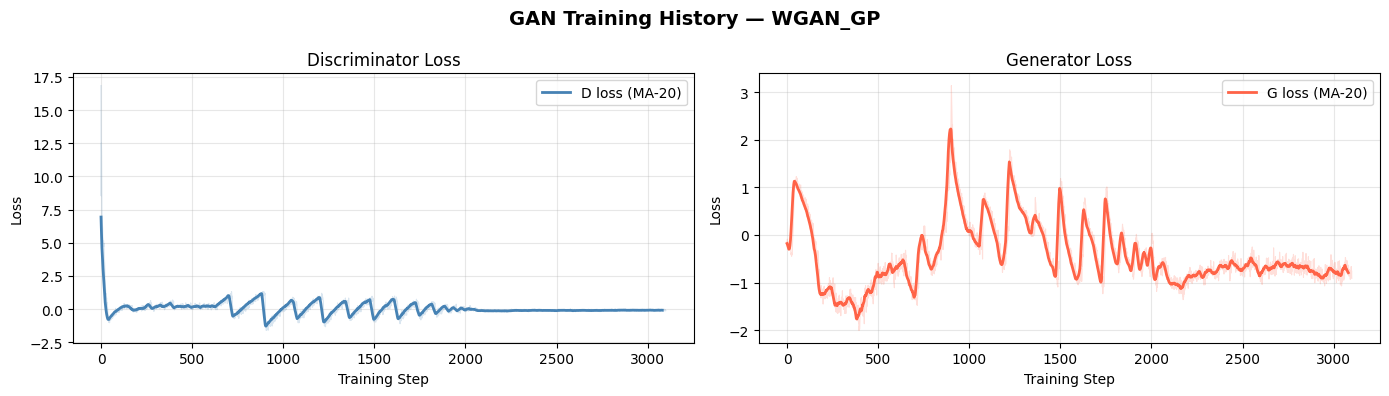

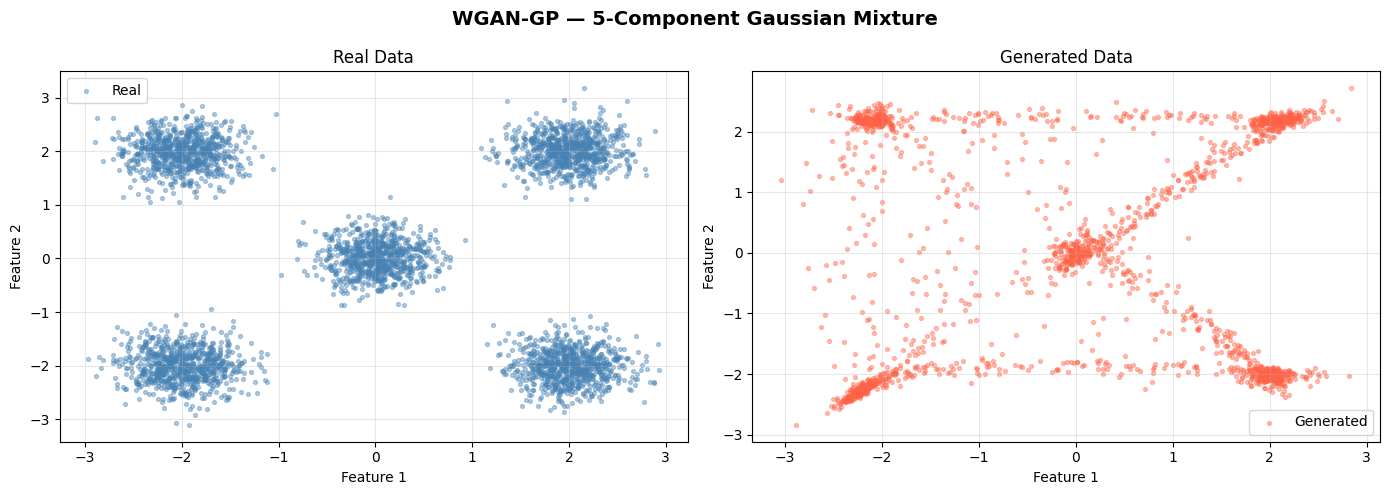

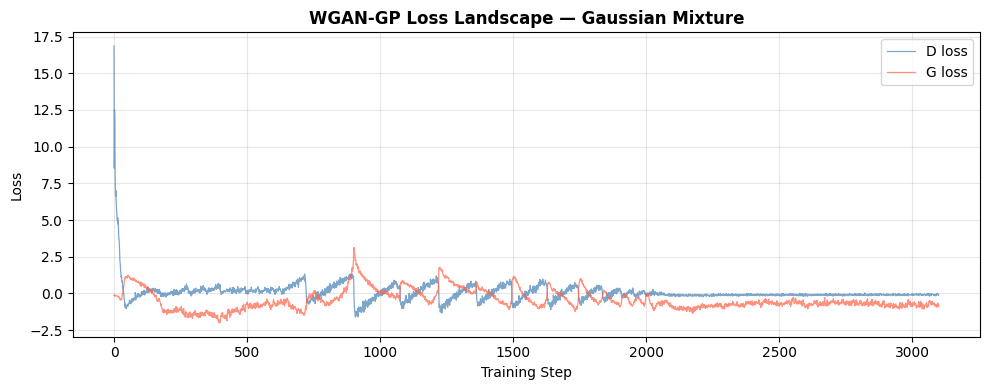

FID proxy: 0.0334
Generator exported → json_model/wgan_gp_gmm_gen.json
BN running stats appended → json_model/wgan_gp_gmm_gen.json
Generated in : arduino_code/wgan_gp_gmm_ino  (board: esp32)
Latent dim   : 8  Output dim: 2
Conditional  : False  Classes: 0
Expected output (Python) : [-0.02869548462331295, -0.3088935911655426] ...


In [4]:
def train_wgan_gp_gmm():
    print('=== Example 2 — WGAN-GP: Gaussian Mixture ===')
    torch.manual_seed(42); np.random.seed(42)

    # ---- Data: 5-component Gaussian mixture ----
    centers = np.array([[0,0],[2,2],[-2,2],[2,-2],[-2,-2]], dtype=np.float32)
    parts = [np.random.randn(800, 2).astype(np.float32) * 0.3 + c for c in centers]
    X = np.concatenate(parts, axis=0)
    np.random.shuffle(X)

    dataset = TensorDataset(torch.FloatTensor(X))
    loader  = DataLoader(dataset, batch_size=128, shuffle=True, drop_last=True)

    LATENT_DIM = 8

    # ---- Architecture ----
    G = Generator(
        latent_dim=LATENT_DIM,
        generator_layers=[
            {'out_features': 256, 'activation': 'relu',   'use_bn': True},
            {'out_features': 256, 'activation': 'relu',   'use_bn': True},
            {'out_features': 2,   'activation': 'linear', 'use_bn': False},
        ],
    )
    D = Discriminator(
        input_dim=2,
        discriminator_layers=[
            {'out_features': 256, 'activation': 'leaky_relu', 'use_ln': True},
            {'out_features': 256, 'activation': 'leaky_relu', 'use_ln': True},
            {'out_features': 1,   'activation': 'linear'},
        ],
    )

    g_opt = optim.Adam(G.parameters(), lr=1e-4, betas=(0.0, 0.9))
    d_opt = optim.Adam(D.parameters(), lr=1e-4, betas=(0.0, 0.9))

    trainer = GANTrainer(
        G, D, g_opt, d_opt,
        loss_type='wgan_gp',
        device=DEVICE,
        n_critic=5,
        lambda_gp=10.0,
    )

    # ---- Train ----
    d_losses, g_losses = trainer.train(loader, epochs=100, print_every=75)

    # ---- Visualize ----
    plot_training_history(d_losses, g_losses, loss_type='wgan_gp')
    plot_generated_samples(G, X, n_samples=2000, device=DEVICE,
                           title='WGAN-GP — 5-Component Gaussian Mixture')
    plot_loss_landscape(d_losses, g_losses,
                        title='WGAN-GP Loss Landscape — Gaussian Mixture')

    fid = evaluate_fid_proxy(G, X, device=DEVICE)
    print(f'FID proxy: {fid:.4f}')

    # ---- Export ----
    G.eval()
    export_to_json(G, 'json_model/wgan_gp_gmm_gen.json')
    add_bn_stats_to_json(G, 'json_model/wgan_gp_gmm_gen.json')
    generate_ino('json_model/wgan_gp_gmm_gen.json',
                 'arduino_code/wgan_gp_gmm_ino', board='esp32')
    return G, D


G2, D2 = train_wgan_gp_gmm()

---
## 4. Example 3 — Conditional GAN (cGAN) on Blobs

A class-conditional GAN generates samples conditioned on an integer class label.  
Both the Generator and Discriminator receive the label as an additional embedding.

**Use case:** Generating class-specific synthetic sensor data for data augmentation on an embedded device.

**Architecture:**
- Generator: label embedding concatenated to z, ConditionalBatchNorm in hidden layers
- Discriminator: label embedding concatenated to x
- Loss: LSGAN (smooth gradients, no label tricks needed)


=== Example 3 — Conditional GAN (cGAN): Three Blobs ===
  Epoch    1/100  |  D loss = 0.47881  |  G loss = 0.47233
  Epoch   50/100  |  D loss = 0.25183  |  G loss = 0.12785
  Epoch  100/100  |  D loss = 0.25164  |  G loss = 0.12751


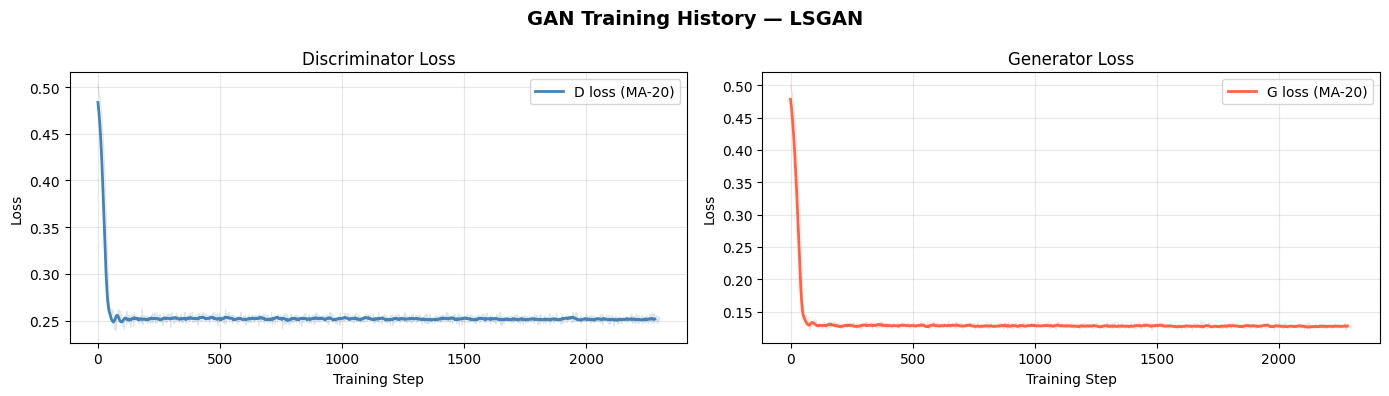

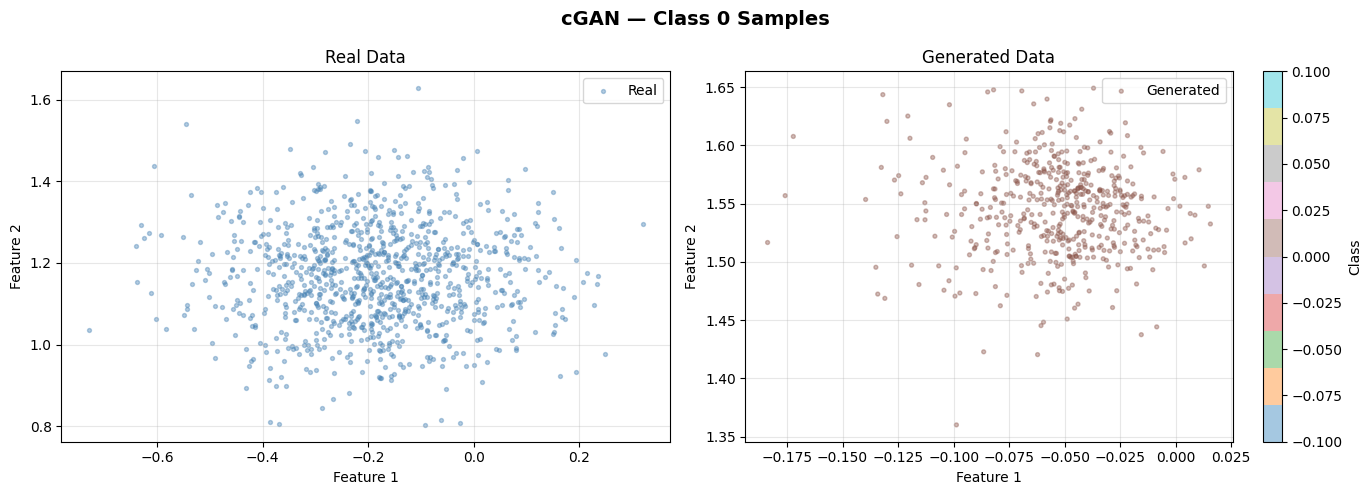

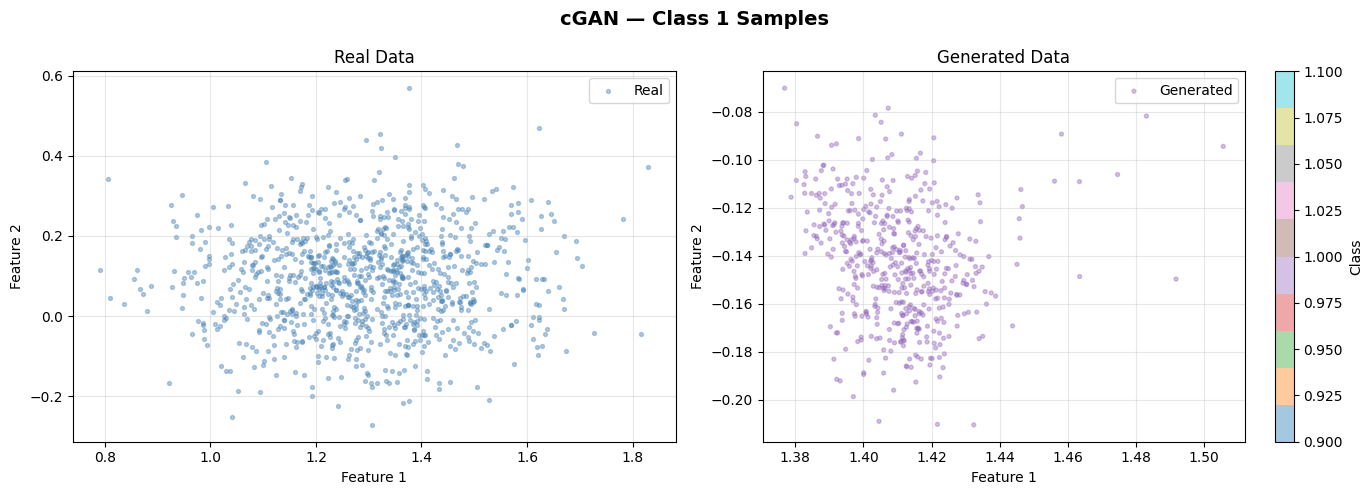

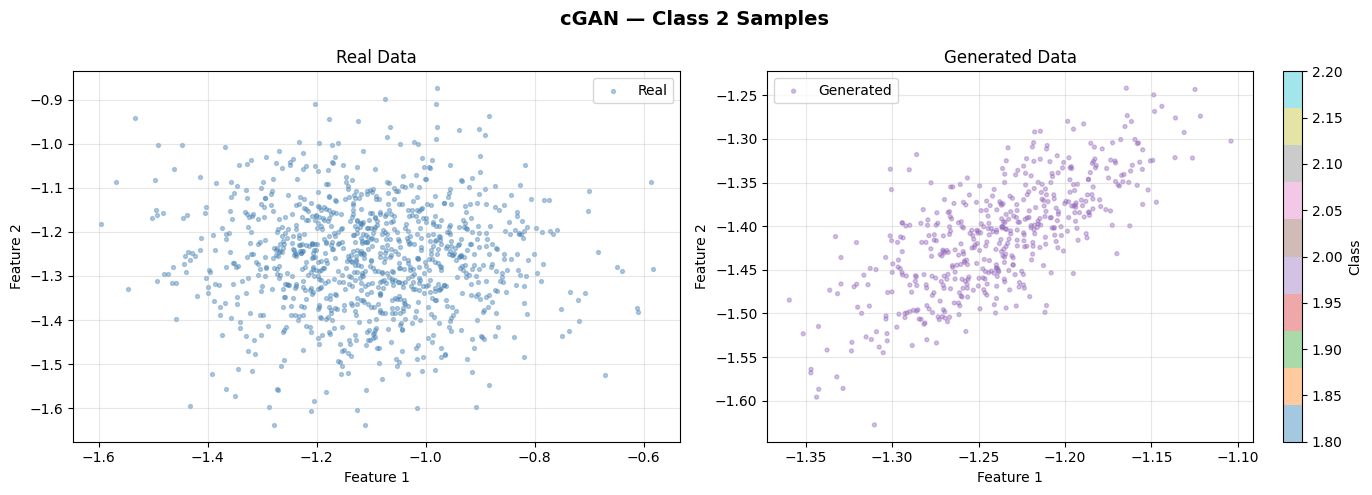

FID proxy (unconditional): 0.0176

Exporting conditional GAN to Arduino C++...
Generator exported → json_model/cgan_blobs.json
BN running stats appended → json_model/cgan_blobs.json
Generated in : arduino_code/cgan_blobs_ino  (board: esp32)
Latent dim   : 4  Output dim: 2
Conditional  : True  Classes: 3
Expected output (Python) : [0.7453944087028503, 0.13941118121147156] ...


In [5]:
def train_cgan_blobs():
    print('=== Example 3 — Conditional GAN (cGAN): Three Blobs ===')
    torch.manual_seed(42)
    np.random.seed(42)

    NUM_CLASSES = 3
    LATENT_DIM = 4

    # ---- Data ----
    from sklearn.datasets import make_blobs
    from sklearn.preprocessing import StandardScaler
    X, y = make_blobs(n_samples=3000, centers=3, cluster_std=0.8, random_state=42)
    scaler = StandardScaler()
    X = scaler.fit_transform(X).astype(np.float32)
    y = y.astype(np.int64)

    dataset = torch.utils.data.TensorDataset(torch.FloatTensor(X), torch.LongTensor(y))
    loader = torch.utils.data.DataLoader(dataset, batch_size=128, shuffle=True, drop_last=True)

    # ---- Architecture ----
    G = Generator(
        latent_dim=LATENT_DIM,
        generator_layers=[
            {'out_features': 128, 'activation': 'relu',   'use_bn': True,
             'num_classes': NUM_CLASSES, 'embed_dim': 32},
            {'out_features': 128, 'activation': 'relu',   'use_bn': True,
             'num_classes': NUM_CLASSES, 'embed_dim': 32},
            {'out_features': 2,   'activation': 'linear', 'use_bn': False},
        ],
        num_classes=NUM_CLASSES,
        embed_dim=32,
    )
    D = Discriminator(
        input_dim=2,
        discriminator_layers=[
            {'out_features': 128, 'activation': 'leaky_relu', 'dropout': 0.2},
            {'out_features': 64,  'activation': 'leaky_relu', 'dropout': 0.2},
            {'out_features': 1,   'activation': 'linear'},
        ],
        num_classes=NUM_CLASSES,
        embed_dim=32,
    )

    g_opt = torch.optim.Adam(G.parameters(), lr=2e-4, betas=(0.5, 0.999))
    d_opt = torch.optim.Adam(D.parameters(), lr=2e-4, betas=(0.5, 0.999))

    trainer = GANTrainer(G, D, g_opt, d_opt, loss_type='lsgan', device=DEVICE)

    # ---- Train ----
    d_losses, g_losses = trainer.train(loader, epochs=100, print_every=50)

    # ---- Visualize ----
    plot_training_history(d_losses, g_losses, loss_type='lsgan')
    for cls in range(NUM_CLASSES):
        lbl = torch.full((500,), cls, dtype=torch.long, device=DEVICE)
        plot_generated_samples(
            G, X[y == cls], n_samples=500, device=DEVICE,
            labels=lbl, num_classes=NUM_CLASSES,
            title=f'cGAN — Class {cls} Samples',
        )

    fid = evaluate_fid_proxy(G, X, device=DEVICE)
    print(f'FID proxy (unconditional): {fid:.4f}')

    # ---- Export for Arduino (now fully supported) ----
    print('\nExporting conditional GAN to Arduino C++...')
    G.eval()
    export_to_json(G, "json_model/cgan_blobs.json")
    add_bn_stats_to_json(G, "json_model/cgan_blobs.json")
    generate_ino("json_model/cgan_blobs.json", "arduino_code/cgan_blobs_ino", board="esp32")

    return G, D



G3, D3 = train_cgan_blobs()

---
## 5. Example 4 — Hinge GAN with Spectral Normalization on Sensor Data

Hinge loss combined with spectral normalization in the Discriminator, applied to
a 4-D synthetic sensor dataset (e.g., accelerometer readings).  
The trained Generator is exported to Arduino C++ for on-device data augmentation.

**Use case:** An embedded device needs to generate plausible sensor readings for
testing anomaly detection thresholds without access to real sensors.

**Architecture:**
- Generator: `16 → 128 → 256 → 4` (BN + ReLU, tanh output)
- Discriminator: `4 → 256 → 128 → 1` (SN + LeakyReLU)
- Loss: Hinge


=== Example 4 — Hinge GAN + Spectral Norm: 4-D Sensor Data ===
  Epoch    1/100  |  D loss = 1.83513  |  G loss = -0.24224
  Epoch   75/100  |  D loss = 1.98631  |  G loss = 0.28070


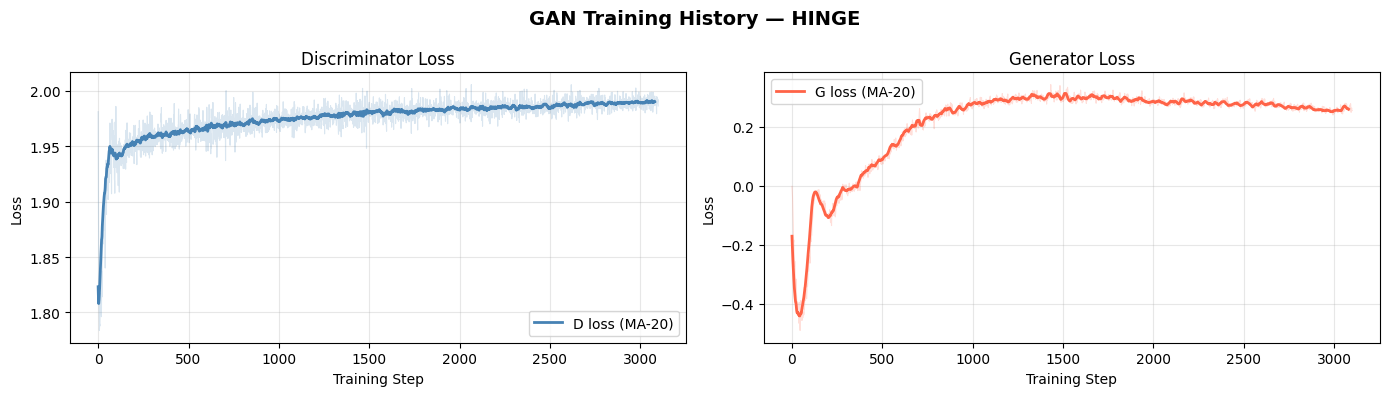

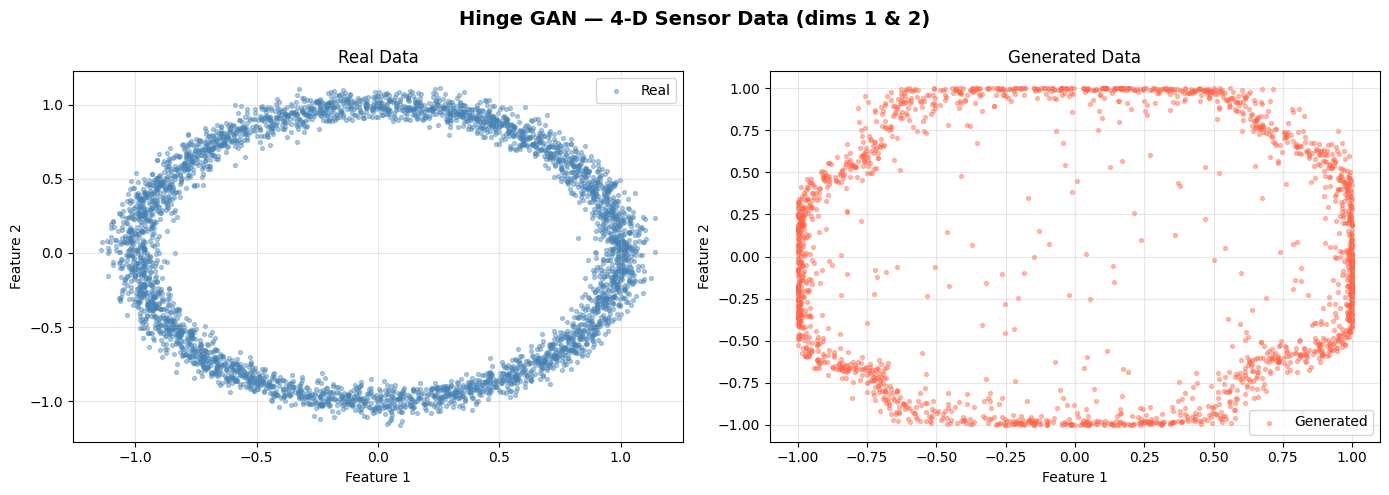

FID proxy: 0.0072
Generator exported → json_model/hinge_sensor_gen.json
BN running stats appended → json_model/hinge_sensor_gen.json
Generated in : arduino_code/hinge_sensor_ino  (board: esp32)
Latent dim   : 16  Output dim: 4
Conditional  : False  Classes: 0
Expected output (Python) : [-0.4835212826728821, -0.2864103615283966, 0.6036390662193298, -0.5060331225395203] ...


In [6]:
def train_hinge_sensor():
    print('=== Example 4 — Hinge GAN + Spectral Norm: 4-D Sensor Data ===')
    torch.manual_seed(42); np.random.seed(42)

    # ---- Synthetic 4-D sensor data ----
    N  = 4000
    t  = np.random.uniform(0, 2 * np.pi, N).astype(np.float32)
    X  = np.stack([
        np.sin(t) + 0.05 * np.random.randn(N).astype(np.float32),
        np.cos(t) + 0.05 * np.random.randn(N).astype(np.float32),
        np.sin(2 * t) + 0.05 * np.random.randn(N).astype(np.float32),
        np.cos(2 * t) + 0.05 * np.random.randn(N).astype(np.float32),
    ], axis=1).astype(np.float32)

    dataset = TensorDataset(torch.FloatTensor(X))
    loader  = DataLoader(dataset, batch_size=128, shuffle=True, drop_last=True)

    LATENT_DIM = 16

    # ---- Architecture ----
    G = Generator(
        latent_dim=LATENT_DIM,
        generator_layers=[
            {'out_features': 128, 'activation': 'relu',   'use_bn': True},
            {'out_features': 256, 'activation': 'relu',   'use_bn': True},
            {'out_features': 4,   'activation': 'tanh',   'use_bn': False},
        ],
    )
    D = Discriminator(
        input_dim=4,
        discriminator_layers=[
            {'out_features': 256, 'activation': 'leaky_relu',
             'spectral_norm': True},
            {'out_features': 128, 'activation': 'leaky_relu',
             'spectral_norm': True},
            {'out_features': 1,   'activation': 'linear',
             'spectral_norm': True},
        ],
    )

    g_opt = optim.Adam(G.parameters(), lr=2e-4, betas=(0.5, 0.999))
    d_opt = optim.Adam(D.parameters(), lr=4e-4, betas=(0.5, 0.999))

    trainer = GANTrainer(
        G, D, g_opt, d_opt,
        loss_type='hinge',
        device=DEVICE,
        n_critic=2,
    )

    # ---- Train ----
    d_losses, g_losses = trainer.train(loader, epochs=100, print_every=75)

    # ---- Visualize (first 2 dims) ----
    plot_training_history(d_losses, g_losses, loss_type='hinge')
    plot_generated_samples(G, X, n_samples=2000, device=DEVICE,
                           title='Hinge GAN — 4-D Sensor Data (dims 1 & 2)')

    fid = evaluate_fid_proxy(G, X, device=DEVICE)
    print(f'FID proxy: {fid:.4f}')

    # ---- Export ----
    G.eval()
    export_to_json(G, 'json_model/hinge_sensor_gen.json')
    add_bn_stats_to_json(G, 'json_model/hinge_sensor_gen.json')
    generate_ino('json_model/hinge_sensor_gen.json',
                 'arduino_code/hinge_sensor_ino', board='esp32')
    return G, D


G4, D4 = train_hinge_sensor()

---
## 6. Quick Reference — Architecture & Hyperparameters

### Generator layer keys

| Key | Type | Default | Description |
|-----|------|---------|-------------|
| `out_features` | int | *required* | Output width |
| `activation` | str | `'relu'` | Activation function |
| `use_bn` | bool | `True` | BatchNorm (hidden) / False (output) |
| `num_classes` | int | `0` | > 0 → ConditionalBatchNorm |
| `embed_dim` | int | `64` | Label embedding dimension |

### Discriminator layer keys

| Key | Type | Default | Description |
|-----|------|---------|-------------|
| `out_features` | int | *required* | Output width |
| `activation` | str | `'leaky_relu'` | Activation |
| `dropout` | float | `0.0` | Dropout probability |
| `use_ln` | bool | `False` | LayerNorm (recommended for WGAN-GP) |
| `spectral_norm` | bool | `False` | Spectral norm (recommended for Hinge) |

### Loss type comparison

| Loss | D updates / G update | Extra hyperparams | Notes |
|------|---------------------|-------------------|-------|
| `vanilla` | 1 | `label_smoothing` | Simple, can saturate |
| `lsgan` | 1 | — | Smooth gradients always |
| `wgan` | 5 | `clip_value` | Requires weight clipping |
| `wgan_gp` | 5 | `lambda_gp=10` | Best stability, recommended |
| `hinge` | 2 | — | Pair with `spectral_norm=True` |

### Example: WGAN-GP with a deeper Generator

```python
G = Generator(
    latent_dim=64,
    generator_layers=[
        {'out_features': 256, 'activation': 'relu',   'use_bn': True},
        {'out_features': 512, 'activation': 'relu',   'use_bn': True},
        {'out_features': 256, 'activation': 'relu',   'use_bn': True},
        {'out_features': 16,  'activation': 'tanh',   'use_bn': False},
    ],
)
D = Discriminator(
    input_dim=16,
    discriminator_layers=[
        {'out_features': 256, 'activation': 'leaky_relu', 'use_ln': True},
        {'out_features': 128, 'activation': 'leaky_relu', 'use_ln': True},
        {'out_features': 1,   'activation': 'linear'},
    ],
)
trainer = GANTrainer(G, D, g_opt, d_opt, loss_type='wgan_gp',
                     n_critic=5, lambda_gp=10.0, device=DEVICE)
```
